# Sobol sensitivity analysis using saved fits to the data

Program to read in the zarr collection holding the fits to compute sobol indices

The FFDI code needed 3-23-.10 but this was not tested using this code.




#### required packages

In [1]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime

from xclim.indices import (
    keetch_byram_drought_index,
    griffiths_drought_factor,
    mcarthur_forest_fire_danger_index
)

%load_ext autoreload
%autoreload 2


# importing sys
import sys
# adding plotting module to the system path
sys.path.insert(0, '/g/data/xv83/rxm599/acs/plotting_maps')
# import ACS plotting maps and Xarray.
from acs_plotting_maps import *
from acs_area_statistics import acs_regional_stats, get_regions

import geopandas as gpd
import pandas as pd
import regionmask

sys.path.insert(0, '/g/data/xv83/rxm599/acs/hazard_fire/paper2')
import sa as sa


ERROR 1: PROJ: proj_create_from_database: Open of /g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/share/proj failed


#### start a local Dask client

In [2]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

2025-08-16 21:43:15,408 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-08-16 21:43:15,412 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-08-16 21:43:15,424 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/31337/proxy/8787/status,
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/31337/proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40295,Workers: 28
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/31337/proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34743,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/31337/proxy/45537/status,Memory: 0 B
Nanny: tcp://127.0.0.1:35729,


In [3]:
import warnings
warnings.filterwarnings('ignore')

## Set parameters

In [4]:
# parameters
# 0,2,3 failed
mindex=1
#lon1=140; lon2=150 
#lat1=-45; lat2= -32
#lat1=-45 lat2= -40 lon1=144 lon2=149
#lon1=145 ; lon2=146
#lat1=-37 ; lat2=-36
lat1=-45
lat2= -10
lon1=110
lon2=155

t1='2015-01-01'
t2='2035-12-31'
dirstore='sa_2020'
mobs=24


## Obtain the desired catalogues of the simulations to processe

In [5]:
dtype='/g/data/ia39/ncra/fire/bias-output/'
zarr_path=dtype+ 'zarr/*ssp370*'
ffdi_path=dtype+'ffdi/*ssp370*FFDI*'
kbdi_path=dtype+'ffdi/*ssp370*KBDI*'
# observations 
zobs='/g/data/ia39/ncra/fire/bias-input/zarr/*ERA*' 
fobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*FFDI*'
kobs='/g/data/ia39/ncra/fire/bias-input/ffdi/*ERA*KBDI*'

mRuns = sorted(glob(zarr_path)) + sorted(glob(zobs))
mFFDI = sorted(glob(ffdi_path))+ sorted(glob(fobs))
mKBDI = sorted(glob(kbdi_path)) + sorted(glob(kobs))
print(len(mRuns))
print(len(mFFDI))

# print code to ensure the files match
ifile=-1
for file in mRuns: 
    ifile=ifile+1
#    print(ifile, file)
ifile=-1
for file in mFFDI: 
    ifile=ifile+1
#    print(ifile, file)

24
24


# Process one ensemble 

In [6]:
# From one catalogue list save variables
ds0=xr.open_zarr(mRuns[mindex])
df0=xr.open_zarr(mFFDI[mindex])
dk0=xr.open_zarr(mKBDI[mindex])

print(mRuns[mindex])
print(mFFDI[mindex])
print(mKBDI[mindex])


# compute DF 
# kbdi has a 20 extra points at the start for DF calculation
if mindex != mobs: 
# for projections    
    pra = ds0.prAdjust.sel(time=slice(ds0.prAdjust.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)
else:
    print("obs")
    pra = ds0.pr.sel(time=slice(ds0.pr.time[0],'2099-12-31'))
    kbdi=dk0.KBDI.sel(time=slice(pra.time[0],pra.time[-1] ))
    DF = griffiths_drought_factor(pra, kbdi)
    
print(pra)
print(kbdi)


0.3.0
/g/data/ia39/ncra/fire/bias-output/zarr/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_FFDI.zarr
/g/data/ia39/ncra/fire/bias-output/ffdi/AUST-05i_BOM_ACCESS-ESM1-5_ssp370_r6i1p1f1_BARPA-R_v1-r1-ACS-QME-BARRAR2-1980-2022_day_KBDI.zarr
<xarray.DataArray 'prAdjust' (time: 31046, lat: 691, lon: 886)>
dask.array<getitem, shape=(31046, 691, 886), dtype=float32, chunksize=(31046, 33, 43), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float64 112.0 112.0 112.1 112.2 ... 156.1 156.2 156.2 156.2
  * time     (time) datetime64[ns] 2015-01-01T12:00:00 ... 2099-12-31T12:00:00
Attributes:
    long_name:      Bias-Adjusted Precipitation
    regrid_method:  bilinear
    standard_name:  lwe_precipitation_rate
    units:          mm d-1
<xarra

In [7]:
# compute the 95% value from first 20 years
if mindex != mobs:
    tr1='2015-01-01'; tr2='2035-12-31'
else:
    tr1='2000-01-01'; tr2='2020-12-31'
    t1=tr1; t2=tr2
#    tr1='2003-01-01'; tr2='2023-12-31'

df1=df0.sel(time=slice(tr1,tr2))
d95a=df1.FFDI.quantile(.95,dim='time')


## mask info

## Read in fit results

In [8]:
%%time
ds1=0; ds2=0
outf1='/scratch/xv83/rxm599/'+f'model_{mindex}_fits.zarr'
print(mindex)
print(outf1)

ds1 = xr.open_zarr(outf1)

1
/scratch/xv83/rxm599/model_1_fits.zarr
CPU times: user 113 ms, sys: 37.6 ms, total: 151 ms
Wall time: 270 ms


In [9]:
%%time
tfit=ds1.tfit.load()
hfit=ds1.hfit.load()
wfit=ds1.wfit.load()
dfit=ds1.dfit.load()

CPU times: user 4.36 s, sys: 849 ms, total: 5.21 s
Wall time: 7.07 s


Text(0.5, 1.0, 'Wmax')

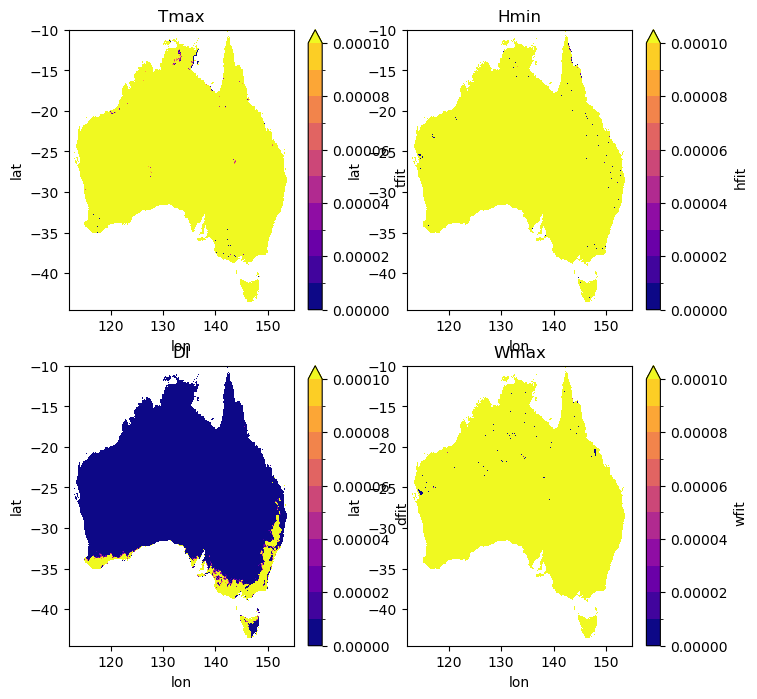

In [10]:
lev1=np.arange(0, 1, .1)
lev1 = np.linspace(0, .0001, 11)
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1); tfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Tmax")
plt.subplot(2,2,2); hfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Hmin")
plt.subplot(2,2,3); dfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("DI")
plt.subplot(2,2,4); wfit.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Wmax")

In [11]:
%%time

def bad(a11): # Find locations where condition is True
    locations = a11 < .0000002
# Stack dimensions into a flat index
    stacked = locations.stack(all_points=("lon", "lat"))
# Get the coordinates where the condition is True
    matching_indices = stacked.where(stacked, drop=True)
# Print the matching indices
#    print(matching_indices.coords)
    count = (matching_indices).sum().item()  # .item() to get Python scalar
    print('number of points=',count)
    return matching_indices

res=bad(tfit.sel(parameter1='p-value'))
res=bad(hfit.sel(parameter1='p-value'))
res=bad(dfit.sel(parameter1='p-value'))
res=bad(wfit.sel(parameter1='p-value'))


number of points= 276.0
number of points= 496.0
number of points= 252645.0
number of points= 726.0
CPU times: user 305 ms, sys: 159 ms, total: 465 ms
Wall time: 359 ms


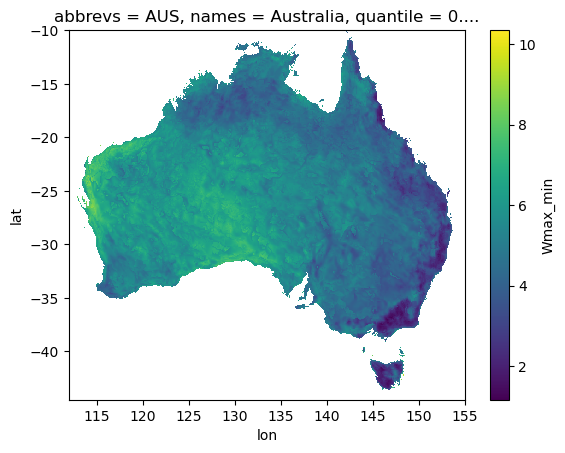

In [12]:
ds1.Wmax_min.plot()

### Do it again with lognorm fits

In [13]:
%%time
outf2='/scratch/xv83/rxm599/'+f'model_{mindex}_lfits.zarr'
print(mindex)
print(outf1)

ds2 = xr.open_zarr(outf2)

1
/scratch/xv83/rxm599/model_1_fits.zarr
CPU times: user 112 ms, sys: 38.2 ms, total: 151 ms
Wall time: 302 ms


In [14]:
%%time
tfit1=ds2.tfit.load()
hfit1=ds2.hfit.load()
wfit1=ds2.wfit.load()
dfit1=ds2.dfit.load()

CPU times: user 3.68 s, sys: 762 ms, total: 4.45 s
Wall time: 4.61 s


Text(0.5, 1.0, 'Wmax')

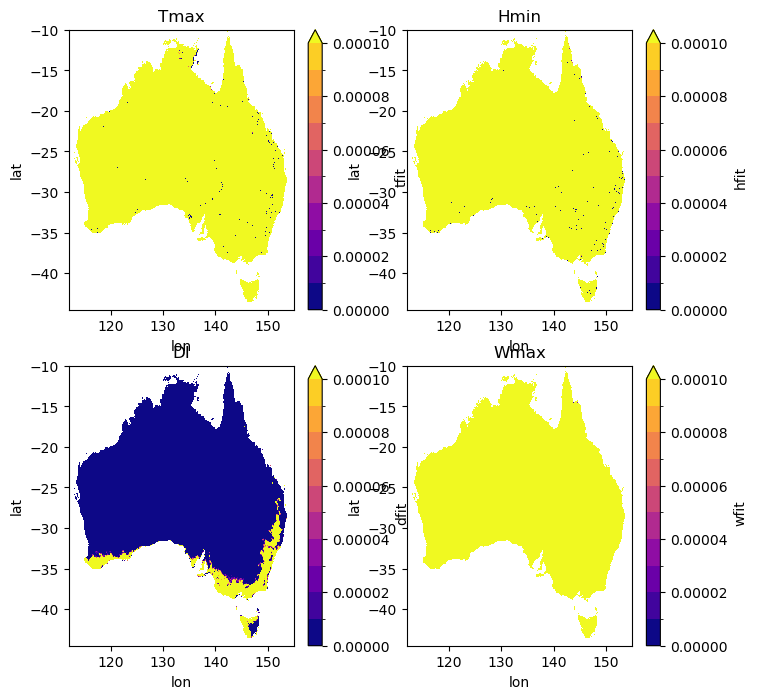

In [15]:
lev1=np.arange(0, 1, .1)
lev1 = np.linspace(0, .0001, 11)
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1); tfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Tmax")
plt.subplot(2,2,2); hfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Hmin")
plt.subplot(2,2,3); dfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("DI")
plt.subplot(2,2,4); wfit1.sel(parameter1='p-value').plot(levels=lev1,cmap='plasma')
plt.title("Wmax")

In [16]:
%%time

res=bad(tfit1.sel(parameter1='p-value'))
res=bad(hfit1.sel(parameter1='p-value'))
res=bad(dfit1.sel(parameter1='p-value'))
res=bad(wfit1.sel(parameter1='p-value'))


number of points= 818.0
number of points= 1057.0
number of points= 250980.0
number of points= 0.0
CPU times: user 195 ms, sys: 57.7 ms, total: 253 ms
Wall time: 211 ms


In [17]:
a1=(tfit.sel(parameter1='p-value') - tfit1.sel(parameter1='p-value'))
#a1.max().values
la=-30;lo=115.05
print(tfit.sel(lon=lo,lat=la).values)
print(tfit1.sel(lon=lo,lat=la).values)

[ 3.24359138e+06 -5.33660864e+03  1.64896719e-03  1.82883302e-01
  3.84711757e-08]
[ 1.12785383e-02 -2.51299962e+02  2.62123101e+02  3.45781945e-02
  9.01837273e-01]


In [18]:
a1=wfit.sel(parameter1='p-value')
a2=wfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=tfit.sel(parameter1='p-value')
a2=tfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=hfit.sel(parameter1='p-value')
a2=hfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)
a1=dfit.sel(parameter1='p-value')
a2=dfit1.sel(parameter1='p-value')
b=xr.apply_ufunc(np.maximum, a1, a2)
res=bad(b)

number of points= 0.0
number of points= 99.0
number of points= 3.0
number of points= 250910.0


In [19]:
#sys.exit(1)

## Sobol Indices

In [20]:
%%time
outf1='/scratch/xv83/rxm599/'+f'model_{mindex}_fits.zarr'
print(mindex)
print(outf1)

ds1 = xr.open_zarr(outf1)
ds1

1
/scratch/xv83/rxm599/model_1_fits.zarr
CPU times: user 53.1 ms, sys: 33.3 ms, total: 86.4 ms
Wall time: 82.7 ms


<xarray.Dataset>
Dimensions:     (lat: 691, lon: 861, parameter1: 5)
Coordinates:
    abbrevs     <U3 ...
  * lat         (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon         (lon) float64 112.0 112.0 112.1 112.2 ... 154.9 154.9 155.0
    names       <U9 ...
  * parameter1  (parameter1) <U7 'a' 'loc' 'scale' 'KS-fit' 'p-value'
    quantile    float64 ...
    region      int64 ...
Data variables:
    DI_min      (lat, lon) float32 dask.array<chunksize=(33, 43), meta=np.ndarray>
    Hmin_min    (lat, lon) float32 dask.array<chunksize=(33, 43), meta=np.ndarray>
    Tmax_min    (lat, lon) float32 dask.array<chunksize=(33, 43), meta=np.ndarray>
    Wmax_min    (lat, lon) float32 dask.array<chunksize=(33, 43), meta=np.ndarray>
    dfit        (lat, lon, parameter1) float64 dask.array<chunksize=(33, 43, 5), meta=np.ndarray>
    hfit        (lat, lon, parameter1) float64 dask.array<chunksize=(33, 43, 5), meta=np.ndarray>
    tfit        (lat, lon, parameter1) float64 dask.array<chunksize=(33, 43, 5), meta=np.ndarray>
    wfit        (lat, lon, parameter1) float64 dask.array<chunksize=(33, 43, 5), meta=np.ndarray>

In [21]:
%%time
tfit=ds1.tfit.load()
hfit=ds1.hfit.load()
wfit=ds1.wfit.load()
dfit=ds1.dfit.load()

t_min=ds1.Tmax_min
h_min=ds1.Hmin_min
w_min=ds1.Wmax_min
d_min=ds1.DI_min

CPU times: user 3.44 s, sys: 700 ms, total: 4.14 s
Wall time: 4.3 s


In [22]:
la=-30;lo=115.05
tfit1=tfit.sel(lat=la,lon=lo).load()
wfit1=wfit.sel(lat=la,lon=lo).load()
dfit1=dfit.sel(lat=la,lon=lo).load()
hfit1=hfit.sel(lat=la,lon=lo).load()

t_min1=t_min.sel(lat=la,lon=lo)#.load()
h_min1=h_min.sel(lat=la,lon=lo)#.load()
w_min1=w_min.sel(lat=la,lon=lo)#.load()
d_min1=d_min.sel(lat=la,lon=lo)#.load()


In [23]:
%%time
sa1,sa2=sa.xr_sobol_indices(tfit1,hfit1,wfit1,dfit1)
print(sa1.values)
print(sa2.values)

sa1=sa.xr_sobol_indices_v2(dfit1,tfit1,hfit1,wfit1,d_min1*0,t_min1*0,h_min1*0,w_min1*0,4096*4)
print(sa1.values)

sa1=sa.xr_sobol_indices_v2(dfit1,tfit1,hfit1,wfit1,d_min1,t_min1,h_min1,w_min1,4096*4)
print(sa1.values)


[0.44658898 0.16884147 0.18816853 0.1729943 ]
[0.46117241 0.17811517 0.19486636 0.18395596]
[[0.41439081 0.15402999 0.16692868 0.1582145 ]
 [0.46644164 0.17294148 0.19519212 0.1836055 ]]
[[0.03151799 0.27014407 0.30338941 0.28232458]
 [0.04812848 0.30049048 0.33803705 0.31860388]]
CPU times: user 1.14 s, sys: 254 ms, total: 1.39 s
Wall time: 3.08 s


In [24]:
%%time
#sa1,sa2=sa.xr_sobol_indices(tfit,hfit,wfit,dfit)
#sa1,sa2=sa.xr_sobol_indices_v2(dfit,tfit,hfit,wfit,d_min,t_min,h_min,w_min,4096*4)
sa1=sa.xr_sobol_indices_v2(dfit,tfit,hfit,wfit,d_min,t_min,h_min,w_min,4096*4)
sa1

CPU times: user 71.4 ms, sys: 5.96 ms, total: 77.3 ms
Wall time: 65.1 ms


<xarray.DataArray 'sobol_indices' (lat: 691, lon: 861, stat: 2, sa_1: 4)>
dask.array<transpose, shape=(691, 861, 2, 4), dtype=float64, chunksize=(33, 43, 2, 4), chunktype=numpy.ndarray>
Coordinates:
    abbrevs   <U3 'AUS'
  * lat       (lat) float64 -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float64 112.0 112.0 112.1 112.2 ... 154.8 154.9 154.9 155.0
    names     <U9 'Australia'
    quantile  float64 0.95
    region    int64 0
  * sa_1      (sa_1) <U4 'DI' 'Tmax' 'Hmin' 'Wmax'
Dimensions without coordinates: stat

In [ ]:
%%time
sa1.load()
lev = np.linspace(0, 1, 21)
lev = np.linspace(0, .5, 21)
plt.figure(figsize=(8, 10))
plt.subplot(4,2,1); sa1.sel(sa_1='DI',stat=0).plot(levels=lev,cmap="coolwarm")
plt.title("DI")
plt.subplot(4,2,2); sa1.sel(sa_1='DI',stat=1).plot(levels=lev,cmap="coolwarm")
plt.title("DI")
plt.subplot(4,2,3); sa1.sel(sa_1='Tmax',stat=0).plot(levels=lev,cmap="coolwarm")
plt.title("Tmax")
plt.subplot(4,2,4); sa1.sel(sa_1='Tmax',stat=1).plot(levels=lev,cmap="coolwarm")
plt.title("Tmax")
plt.subplot(4,2,5); sa1.sel(sa_1='Hmin',stat=0).plot(levels=lev,cmap="coolwarm")
plt.title("Hmin")
plt.subplot(4,2,6); sa1.sel(sa_1='Hmin',stat=1).plot(levels=lev,cmap="coolwarm")
plt.title("Hmin")
plt.subplot(4,2,7); sa1.sel(sa_1='Wmax',stat=0).plot(levels=lev,cmap="coolwarm")
plt.title("Wmax")
plt.subplot(4,2,8); sa1.sel(sa_1='Wmax',stat=1).plot(levels=lev,cmap="coolwarm")
plt.title("Wmax")


/g/data/xv83/rxm599/acs/hazard_fire/paper2/sa.py:154: RuntimeWarning: invalid value encountered in power
  x[0]**0.987 * np.exp(0.0338 * x[1] - 0.0345 * x[2]
/g/data/xv83/rxm599/acs/hazard_fire/paper2/sa.py:154: RuntimeWarning: invalid value encountered in power
  x[0]**0.987 * np.exp(0.0338 * x[1] - 0.0345 * x[2]
/g/data/xv83/rxm599/acs/hazard_fire/paper2/sa.py:154: RuntimeWarning: invalid value encountered in power
  x[0]**0.987 * np.exp(0.0338 * x[1] - 0.0345 * x[2]
/g/data/xv83/rxm599/acs/hazard_fire/paper2/sa.py:154: RuntimeWarning: invalid value encountered in power
  x[0]**0.987 * np.exp(0.0338 * x[1] - 0.0345 * x[2]


In [ ]:
%%time
outf1='/scratch/xv83/rxm599/'+f'model_{mindex}_sa.nc'
print(mindex)
print(outf1)
sa1.name='SA'
#ds = xr.merge([sa1,sa2])  #,dfit,dfitb])

sa1.to_netcdf(outf1,mode='w')


In [ ]:
#client.shutdown()